# This notebook contains examples on simulated data

In [1]:
import os, sys

cwd = os.getcwd()
grandparent_dir = os.path.abspath(os.path.join(cwd, os.pardir, os.pardir))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

import numpy as np
import pandas as pd
import random
from statsmodels.tsa.statespace.dynamic_factor_mq import DynamicFactorMQ as DFM
import tensorflow as tf

from models.ddfm import DDFM
from synthetic_dgp.simulate import SIMULATE

In [2]:
import logging

logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("Logger Level Info")
tf.get_logger().setLevel("ERROR")

INFO:root:Logger Level Info


In [3]:
seed = 123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
# set poly degree, if 1 then linear and the encoder structure is modified to linear single layer
poly_degree = 2
# init results storage
results_dfm = np.zeros(2)
results_ddfm = np.zeros(3)
results_ddfm_nnlin_dec = np.zeros(2)
# params sim data
n_obs = 150
r = 3
portion_missings = 0.2
# simulate data
sim_40 = SIMULATE(seed=seed, n=40, r=r, poly_degree=poly_degree)
sim_150 = SIMULATE(seed=seed, n=150, r=r, poly_degree=poly_degree)

## Simulate data 40 observables

In [4]:
x = sim_40.simulate(n_obs, portion_missings=portion_missings)
r_f_and_nnlinf = sim_40.f.shape[1]
if poly_degree == 1:
    # For linear
    structure_encoder = (r_f_and_nnlinf,)
else:
    structure_encoder = (
        r_f_and_nnlinf * 6,
        r_f_and_nnlinf * 4,
        r_f_and_nnlinf * 2,
        r_f_and_nnlinf,
    )
# for nonlinear decoder
structure_encoder_nnlin = (r_f_and_nnlinf, r * 9, r * 6, r * 3, r)
structure_decoder_nnlin = (r * 3, r * 6, r * 9, r_f_and_nnlinf)

In [5]:
%%time
# estimate dfm
dyn_fact_mdl = DFM(
    pd.DataFrame(x), factors=min(r_f_and_nnlinf, x.shape[1]), factor_orders=1
)
res_dyn_fact_mdl = dyn_fact_mdl.fit(disp=1000, maxiter=10000)

EM start iterations, llf=-4220.5
EM converged at iteration 357, llf=-3829.3, convergence criterion=9.9857e-07 < tolerance=1e-06
CPU times: total: 3min 35s
Wall time: 27.4 s


In [6]:
results_dfm[0] = sim_40.evaluate(
    res_dyn_fact_mdl.factors["smoothed"].values, f_true=sim_40.f
)
results_dfm[1] = sim_40.evaluate(
    res_dyn_fact_mdl.factors["filtered"].values, f_true=sim_40.f
)
print(results_dfm)

[0.73493439 0.73258482]


In [7]:
%%time
# estimate ddfm (with linear decoder)
deep_dyn_fact_mdl = DDFM(
    structure_encoder=structure_encoder,
    factor_order=1,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl.fit(pd.DataFrame(x), build_state_space=True)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


INFO:DDFM:iteration: 10 - new loss: 0.15839487013887743 - delta: 0.005578592023153379
INFO:DDFM:Convergence achieved in 18 iterations - new loss: 0.15345790248993077 - delta: 0.000293469720092388 < 0.0005


CPU times: total: 36.9 s
Wall time: 23.8 s


In [8]:
results_ddfm[0] = sim_40.evaluate(
    np.mean(deep_dyn_fact_mdl.factors_ae, axis=0), f_true=sim_40.f
)
results_ddfm[1] = sim_40.evaluate(deep_dyn_fact_mdl.factors_filtered, f_true=sim_40.f)
results_ddfm[2] = sim_40.evaluate(deep_dyn_fact_mdl.factors_smoothed, f_true=sim_40.f)
print(results_ddfm)

[0.83310044 0.77666115 0.77479698]


In [9]:
%%time
# estimate ddfm (with nonlinear decoder)
deep_dyn_fact_mdl_nnlin = DDFM(
    structure_encoder=structure_encoder_nnlin,
    factor_order=1,
    var_loss_weight=0,
    structure_decoder=structure_decoder_nnlin,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl_nnlin.fit(pd.DataFrame(x))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


INFO:DDFM:iteration: 10 - new loss: 0.2082571079394519 - delta: 0.009797931344498419
INFO:DDFM:Convergence achieved in 19 iterations - new loss: 0.19942473519445442 - delta: 0.000436794445144411 < 0.0005


CPU times: total: 40 s
Wall time: 29.5 s


In [10]:
results_ddfm_nnlin_dec[0] = sim_40.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin.last_neurons, axis=0), f_true=sim_40.f
)
results_ddfm_nnlin_dec[1] = sim_40.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin.factors_ae, axis=0), f_true=sim_40.linear_f
)
print("last neurons", results_ddfm_nnlin_dec[0])
print("code layer against linear f", results_ddfm_nnlin_dec[1])

last neurons 0.9206511645316297
code layer against linear f 0.1724965825209937


In [11]:
%%time
# estimate ddfm (with nonlinear decoder and joint var estimation)
deep_dyn_fact_mdl_nnlin_jest = DDFM(
    structure_encoder=structure_encoder_nnlin,
    factor_order=1,
    var_loss_weight=1.0,
    structure_decoder=structure_decoder_nnlin,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl_nnlin_jest.fit(pd.DataFrame(x))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


INFO:DDFM:iteration: 10 - new loss: 0.24200507998466492 - delta: 0.022833362206329432
INFO:DDFM:iteration: 20 - new loss: 0.2218467742204666 - delta: 0.008407146887504767
INFO:DDFM:iteration: 30 - new loss: 0.21485136449337006 - delta: 0.008444658017401945
INFO:DDFM:iteration: 40 - new loss: 0.2120417207479477 - delta: 3.162354877770338e-06
INFO:DDFM:Convergence achieved in 40 iterations - new loss: 0.2120417207479477 - delta: 3.162354877770338e-06 < 0.0005


CPU times: total: 55 s
Wall time: 39.2 s


In [12]:
results_ddfm_nnlin_dec[0] = sim_40.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin_jest.last_neurons, axis=0), f_true=sim_40.f
)
results_ddfm_nnlin_dec[1] = sim_40.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin_jest.factors_ae, axis=0), f_true=sim_40.linear_f
)
print("last neurons", results_ddfm_nnlin_dec[0])
print("code layer against linear f", results_ddfm_nnlin_dec[1])

last neurons 0.9236584819634082
code layer against linear f 0.1511500087744618



## Simulate data 150 observables

In [13]:
x = sim_150.simulate(n_obs, portion_missings=portion_missings)
r_f_and_nnlinf = sim_150.f.shape[1]
if poly_degree == 1:
    # For linear to set the following
    structure_encoder = (r_f_and_nnlinf,)
else:
    structure_encoder = (
        r_f_and_nnlinf * 6,
        r_f_and_nnlinf * 4,
        r_f_and_nnlinf * 2,
        r_f_and_nnlinf,
    )
# for nonlinear decoder
structure_encoder_nnlin = (r_f_and_nnlinf, r * 9, r * 6, r * 3, r)
structure_decoder_nnlin = (r * 3, r * 6, r * 9, r_f_and_nnlinf)

In [14]:
%%time
# estimate dfm
dyn_fact_mdl = DFM(
    pd.DataFrame(x), factors=min(r_f_and_nnlinf, x.shape[1]), factor_orders=1
)
res_dyn_fact_mdl = dyn_fact_mdl.fit(disp=1000, maxiter=1000)

EM start iterations, llf=-11404
EM converged at iteration 294, llf=-10229, convergence criterion=9.9724e-07 < tolerance=1e-06
CPU times: total: 27min 57s
Wall time: 3min 54s


In [15]:
results_dfm[0] = sim_150.evaluate(
    res_dyn_fact_mdl.factors["smoothed"].values, f_true=sim_150.f
)
results_dfm[1] = sim_150.evaluate(
    res_dyn_fact_mdl.factors["filtered"].values, f_true=sim_150.f
)
print(results_dfm)

[0.76762413 0.7675039 ]


In [16]:
%%time
# estimate ddfm
deep_dyn_fact_mdl = DDFM(
    structure_encoder=structure_encoder,
    factor_order=1,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl.fit(pd.DataFrame(x), build_state_space=True)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


INFO:DDFM:Convergence achieved in 8 iterations - new loss: 0.21003851862058784 - delta: 0.00016836481432718324 < 0.0005


CPU times: total: 1min 11s
Wall time: 27.1 s


In [17]:
results_ddfm[0] = sim_150.evaluate(
    np.mean(deep_dyn_fact_mdl.factors_ae, axis=0), f_true=sim_150.f
)
results_ddfm[1] = sim_150.evaluate(deep_dyn_fact_mdl.factors_filtered, f_true=sim_150.f)
results_ddfm[2] = sim_150.evaluate(deep_dyn_fact_mdl.factors_smoothed, f_true=sim_150.f)
print(results_ddfm)

[0.90859254 0.79900842 0.79977619]


In [18]:
%%time
# estimate ddfm (with nonlinear decoder)
deep_dyn_fact_mdl_nnlin = DDFM(
    structure_encoder=structure_encoder_nnlin,
    factor_order=1,
    var_loss_weight=0,
    structure_decoder=structure_decoder_nnlin,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl_nnlin.fit(pd.DataFrame(x))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


INFO:DDFM:iteration: 10 - new loss: 0.2499650591424426 - delta: 0.004310720925234119
INFO:DDFM:iteration: 20 - new loss: 0.24239291011161812 - delta: 0.005049801312434067
INFO:DDFM:Convergence achieved in 23 iterations - new loss: 0.2405822546332742 - delta: 0.00021775943424131114 < 0.0005


CPU times: total: 53 s
Wall time: 36.9 s


In [19]:
results_ddfm_nnlin_dec[0] = sim_150.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin.last_neurons, axis=0), f_true=sim_150.f
)
results_ddfm_nnlin_dec[1] = sim_150.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin.factors_ae, axis=0), f_true=sim_150.linear_f
)
print("last neurons", results_ddfm_nnlin_dec[0])
print("code layer against linear f", results_ddfm_nnlin_dec[1])

last neurons 0.8625497006948423
code layer against linear f 0.2265984943910817


In [20]:
%%time
# estimate ddfm (with nonlinear decoder and joint var estimation)
deep_dyn_fact_mdl_nnlin_jest = DDFM(
    structure_encoder=structure_encoder_nnlin,
    factor_order=1,
    var_loss_weight=1.0,
    structure_decoder=structure_decoder_nnlin,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl_nnlin_jest.fit(pd.DataFrame(x))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


INFO:DDFM:iteration: 10 - new loss: 0.2675952911376953 - delta: 0.015550257211303499
INFO:DDFM:Convergence achieved in 16 iterations - new loss: 0.25974205136299133 - delta: 9.981720830294745e-05 < 0.0005


CPU times: total: 45.1 s
Wall time: 32.6 s


In [21]:
results_ddfm_nnlin_dec[0] = sim_150.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin_jest.last_neurons, axis=0), f_true=sim_150.f
)
results_ddfm_nnlin_dec[1] = sim_150.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin_jest.factors_ae, axis=0), f_true=sim_150.linear_f
)
print("last neurons", results_ddfm_nnlin_dec[0])
print("code layer against linear f", results_ddfm_nnlin_dec[1])

last neurons 0.9358576698784539
code layer against linear f 0.21614898362396473


<Axes: title={'center': 'True Factors'}>

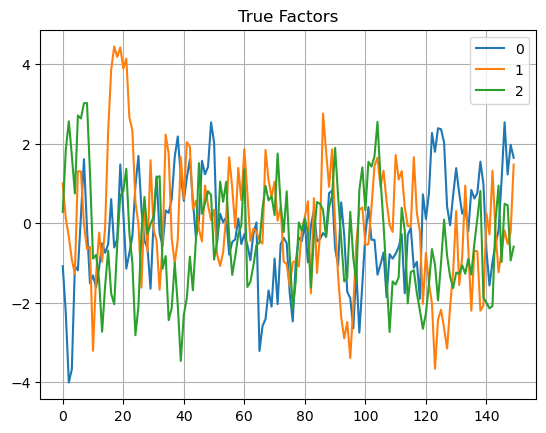

In [22]:
pd.DataFrame(sim_150.linear_f).plot(grid=True, title="True Factors")

<Axes: title={'center': 'Estimated Factors'}>

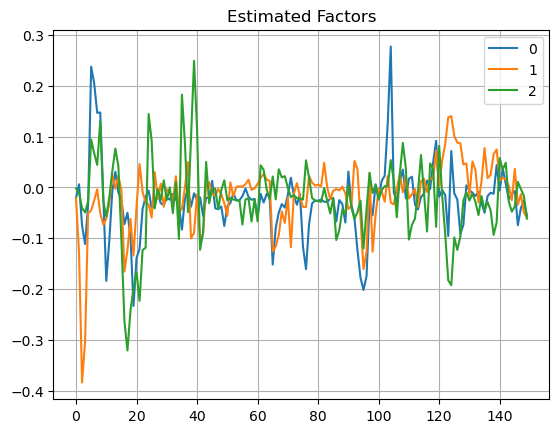

In [23]:
pd.DataFrame(np.mean(deep_dyn_fact_mdl_nnlin_jest.factors_ae, axis=0)).plot(
    grid=True, title="Estimated Factors"
)